# EmpathBot — Dataset Preparation Pipeline
**CS731 Group 14 | Preeti · TJ · Kanishka**

This notebook covers **Tasks 2 → 7** from the project task list:

| Task | Description |
|------|-------------|
| Task 2 | Download & verify AffectNet-HQ |
| Task 3 | Download & verify RAF-DB |
| Task 4 | Download & verify SFEW |
| Task 5 | Apply EmpathBot emotion label mapping |
| Task 6 | YOLO face detection filter + crop (blocking ⛔) |
| Task 7 | Merge, stratified split, save `master_split.csv` + class weights |

> **Run cells top-to-bottom.** Each section prints a verification summary so you can confirm the step worked before moving on.


## 0 — Install & import dependencies

In [2]:
# Install required packages (run once)
import subprocess, sys

pkgs = [
    "torch torchvision",
    "ultralytics",
    "opencv-python-headless",
    "albumentations",
    "pandas numpy matplotlib seaborn",
    "scikit-learn",
    "Pillow",
    "tqdm",
    "kaggle",
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + p.split(), check=False)

print("✅ All packages installed")

✅ All packages installed


In [3]:
import os, shutil, json, csv, random, warnings
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import torch

import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet", "datasets", "huggingface_hub"],
    check=False
)

from datasets import load_dataset
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print("✅ All imports OK")

/Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0 | CUDA: False
✅ All imports OK


## 1 — Project folder structure

Set `BASE_DIR` to wherever you store your datasets.  
Everything else is created automatically.


In [4]:
# ── CONFIGURE THESE PATHS ────────────────────────────────────────────────────
BASE_DIR        = Path("data")                      # root data folder
RAW_AFFECTNET   = BASE_DIR / "raw" / "affectnet_hq" # unzipped AffectNet-HQ
RAW_RAFDB       = BASE_DIR / "raw" / "rafdb"         # unzipped RAF-DB
RAW_SFEW        = BASE_DIR / "raw" / "sfew"          # unzipped SFEW

PROCESSED_DIR   = BASE_DIR / "processed"
AFFECTNET_PROC  = PROCESSED_DIR / "affectnet"
RAFDB_PROC      = PROCESSED_DIR / "rafdb"
SFEW_PROC       = PROCESSED_DIR / "sfew"

SPLIT_CSV       = BASE_DIR / "master_split.csv"
WEIGHTS_JSON    = BASE_DIR / "class_weights.json"

# ── Create all folders ────────────────────────────────────────────────────────
for d in [RAW_AFFECTNET, RAW_RAFDB, RAW_SFEW,
          AFFECTNET_PROC, RAFDB_PROC, SFEW_PROC]:
    d.mkdir(parents=True, exist_ok=True)

print("Folder structure:")
for d in sorted(BASE_DIR.rglob("*")):
    if d.is_dir():
        print(f"  {d}")
print("\n✅ All folders ready")

Folder structure:
  data/AffectNet-HQ
  data/AffectNet-HQ/train
  data/AffectNet-HQ/train/anger
  data/AffectNet-HQ/train/disgust
  data/AffectNet-HQ/train/fear
  data/AffectNet-HQ/train/happy
  data/AffectNet-HQ/train/neutral
  data/AffectNet-HQ/train/sad
  data/AffectNet-HQ/train/surprise
  data/processed
  data/processed/affectnet
  data/processed/affectnet/0
  data/processed/affectnet/1
  data/processed/affectnet/2
  data/processed/affectnet/3
  data/processed/affectnet/4
  data/processed/affectnet/5
  data/processed/rafdb
  data/processed/rafdb/0
  data/processed/rafdb/1
  data/processed/rafdb/2
  data/processed/rafdb/3
  data/processed/rafdb/4
  data/processed/rafdb/5
  data/processed/sfew
  data/processed/sfew/0
  data/processed/sfew/1
  data/processed/sfew/2
  data/processed/sfew/3
  data/processed/sfew/4
  data/processed/sfew/5
  data/raw
  data/raw/affectnet_hq
  data/raw/affectnet_hq/0
  data/raw/affectnet_hq/1
  data/raw/affectnet_hq/2
  data/raw/affectnet_hq/3
  data/raw/a

## 2 — EmpathBot emotion label mapping (Task 5)

Before touching any images, define the canonical mapping from each dataset's
original labels → our 6 trainable EmpathBot classes.

> Class 6 `fake_politeness` is **inference-time only** — no training samples.


In [7]:
# ── EmpathBot class definitions ───────────────────────────────────────────────
EMPATHBOT_CLASSES = {
    0: "neutral",
    1: "trust_relief",
    2: "sadness",
    3: "fear_anxiety",
    4: "confusion",
    5: "distrust",
    # 6: fake_politeness — synthetic, inference only
}
NUM_CLASSES = len(EMPATHBOT_CLASSES)

# ── AffectNet-HQ  (0-indexed folders: 0..7) ──────────────────────────────────
# Original:  0=Neutral 1=Happy 2=Sad 3=Surprise 4=Fear 5=Disgust 6=Anger 7=Contempt
AFFECTNET_MAP = {
    0: 0,   # Neutral       → neutral
    1: 1,   # Happy         → trust_relief
    2: 2,   # Sad           → sadness
    3: 4,   # Surprise      → confusion
    4: 3,   # Fear          → fear_anxiety
    5: 5,   # Disgust       → distrust
    6: 5,   # Anger         → distrust
    7: 5,   # Contempt      → distrust
}

# ── RAF-DB  (1-indexed in list_patition_label.txt) ────────────────────────────
# Original:  1=Surprise 2=Fear 3=Disgust 4=Happy 5=Sad 6=Angry 7=Neutral
RAFDB_MAP = {
    1: 4,   # Surprise      → confusion
    2: 3,   # Fear          → fear_anxiety
    3: 5,   # Disgust       → distrust
    4: 1,   # Happy         → trust_relief
    5: 2,   # Sad           → sadness
    6: 5,   # Angry         → distrust
    7: 0,   # Neutral       → neutral
}

# ── SFEW  (eval only — same 7 labels as RAF-DB convention) ────────────────────
SFEW_MAP = RAFDB_MAP.copy()

# ── Quick sanity check ────────────────────────────────────────────────────────
print("EmpathBot classes:")
for k, v in EMPATHBOT_CLASSES.items():
    print(f"  {k}: {v}")

print("\nAffectNet → EmpathBot:")
aff_orig = {0:"Neutral",1:"Happy",2:"Sad",3:"Surprise",4:"Fear",5:"Disgust",6:"Anger",7:"Contempt"}
for orig_id, eb_id in AFFECTNET_MAP.items():
    print(f"  AffectNet {orig_id} ({aff_orig[orig_id]:10s}) → EmpathBot {eb_id} ({EMPATHBOT_CLASSES[eb_id]})")

print("\nRAF-DB → EmpathBot:")
raf_orig = {1:"Surprise",2:"Fear",3:"Disgust",4:"Happy",5:"Sad",6:"Angry",7:"Neutral"}
for orig_id, eb_id in RAFDB_MAP.items():
    print(f"  RAF-DB   {orig_id} ({raf_orig[orig_id]:10s}) → EmpathBot {eb_id} ({EMPATHBOT_CLASSES[eb_id]})")

# Verify all outputs are in 0..5
assert all(v in range(6) for v in AFFECTNET_MAP.values()), "AffectNet map out of range!"
assert all(v in range(6) for v in RAFDB_MAP.values()),    "RAF-DB map out of range!"
print("\n✅ All mappings valid (outputs in 0–5)")

EmpathBot classes:
  0: neutral
  1: trust_relief
  2: sadness
  3: fear_anxiety
  4: confusion
  5: distrust

AffectNet → EmpathBot:
  AffectNet 0 (Neutral   ) → EmpathBot 0 (neutral)
  AffectNet 1 (Happy     ) → EmpathBot 1 (trust_relief)
  AffectNet 2 (Sad       ) → EmpathBot 2 (sadness)
  AffectNet 3 (Surprise  ) → EmpathBot 4 (confusion)
  AffectNet 4 (Fear      ) → EmpathBot 3 (fear_anxiety)
  AffectNet 5 (Disgust   ) → EmpathBot 5 (distrust)
  AffectNet 6 (Anger     ) → EmpathBot 5 (distrust)
  AffectNet 7 (Contempt  ) → EmpathBot 5 (distrust)

RAF-DB → EmpathBot:
  RAF-DB   1 (Surprise  ) → EmpathBot 4 (confusion)
  RAF-DB   2 (Fear      ) → EmpathBot 3 (fear_anxiety)
  RAF-DB   3 (Disgust   ) → EmpathBot 5 (distrust)
  RAF-DB   4 (Happy     ) → EmpathBot 1 (trust_relief)
  RAF-DB   5 (Sad       ) → EmpathBot 2 (sadness)
  RAF-DB   6 (Angry     ) → EmpathBot 5 (distrust)
  RAF-DB   7 (Neutral   ) → EmpathBot 0 (neutral)

✅ All mappings valid (outputs in 0–5)


## 3 — Verify AffectNet-HQ dataset (Task 2)

Expected structure:
```
data/raw/affectnet_hq/
    0/   ← Neutral
    1/   ← Happy
    ...
    7/   ← Contempt
```


In [8]:
# ── Paths (must match the rest of this notebook) ──────────────────────────────
BASE_DIR       = Path("data")
RAW_AFFECTNET  = BASE_DIR / "raw" / "affectnet_hq"   # numbered folders 0-6
AFFECTNET_ROOT = BASE_DIR / "AffectNet-HQ"            # named emotion folders

# ── HuggingFace label ordering for Piro17/affectnethq ────────────────────────
# HF index:  0=anger  1=disgust  2=fear  3=happy  4=neutral  5=sad  6=surprise
# AffectNet original numbering (used as subfolder names in this notebook):
#   0=Neutral  1=Happy  2=Sad  3=Surprise  4=Fear  5=Disgust  6=Anger
HF_LABEL_NAME    = {0:"anger", 1:"disgust", 2:"fear", 3:"happy",
                    4:"neutral", 5:"sad",    6:"surprise"}
HF_TO_AFFECTNET  = {0:6, 1:5, 2:4, 3:1, 4:0, 5:2, 6:3}

print("Loading AffectNet-HQ from HuggingFace (Piro17/affectnethq)…")
print("(first run downloads ~5.8 GB — subsequent runs use the local HF cache)")

ds_aff = load_dataset("Piro17/affectnethq", split="train")
print(f"✅ Dataset loaded  —  {len(ds_aff):,} images  |  features: {list(ds_aff.features.keys())}")

Loading AffectNet-HQ from HuggingFace (Piro17/affectnethq)…
(first run downloads ~5.8 GB — subsequent runs use the local HF cache)


✅ Dataset loaded  —  27,823 images  |  features: ['image', 'label']


In [9]:
# # ── Save to disk ──────────────────────────────────────────────────────────────
# saved = skipped = 0

# for idx, sample in enumerate(tqdm(ds_aff, desc="Saving AffectNet-HQ")):
#     img      = sample["image"]          # PIL Image
#     hf_label = int(sample["label"])

#     # 1. Numbered folder  → data/raw/affectnet_hq/{0..6}/
#     affectnet_num = HF_TO_AFFECTNET[hf_label]
#     path_num = RAW_AFFECTNET / str(affectnet_num) / f"{idx:06d}.jpg"

#     # 2. Named folder     → data/AffectNet-HQ/train/{emotion}/
#     emotion_name = HF_LABEL_NAME[hf_label]
#     path_name = AFFECTNET_ROOT / "train" / emotion_name / f"{idx:06d}.jpg"

#     already_done = path_num.exists() and path_name.exists()
#     if already_done:
#         skipped += 1
#         continue

#     if not isinstance(img, Image.Image):
#         img = Image.fromarray(img)
#     rgb = img.convert("RGB")

#     path_num.parent.mkdir(parents=True, exist_ok=True)
#     rgb.save(path_num, "JPEG", quality=95)

#     path_name.parent.mkdir(parents=True, exist_ok=True)
#     rgb.save(path_name, "JPEG", quality=95)

#     saved += 1

# print(f"\nAffectNet-HQ  →  saved: {saved:,}  |  skipped (already exist): {skipped:,}")
# print(f"  Numbered structure : {RAW_AFFECTNET}/")
# print(f"  Named structure    : {AFFECTNET_ROOT}/train/")

# # Quick count per class
# print("\nImages per class folder:")
# for hf_idx in range(7):
#     folder = RAW_AFFECTNET / str(HF_TO_AFFECTNET[hf_idx])
#     n = len(list(folder.glob("*.jpg"))) if folder.exists() else 0
#     print(f"  {HF_TO_AFFECTNET[hf_idx]} ({HF_LABEL_NAME[hf_idx]:9s}): {n:,}")
# print("\n✅ AffectNet-HQ download complete")

In [10]:
def verify_affectnet(root: Path) -> pd.DataFrame:
    """Count images per class and check for corrupt files."""
    records = []
    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

    class_dirs = sorted([d for d in root.iterdir() if d.is_dir() and d.name.isdigit()],
                         key=lambda d: int(d.name))

    if not class_dirs:
        print(f"⚠️  No class folders found in {root}")
        print("    Make sure AffectNet-HQ is unzipped into:", root)
        return pd.DataFrame()

    corrupt = 0
    for cls_dir in tqdm(class_dirs, desc="Scanning AffectNet-HQ"):
        orig_id = int(cls_dir.name)
        eb_id   = AFFECTNET_MAP.get(orig_id, -1)
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT]
        for img_path in imgs:
            try:
                img = Image.open(img_path)
                img.verify()
                records.append({
                    "path":       str(img_path),
                    "dataset":    "affectnet",
                    "orig_label": orig_id,
                    "eb_label":   eb_id,
                    "split":      None,
                })
            except Exception:
                corrupt += 1

    df = pd.DataFrame(records)
    print(f"\nAffectNet-HQ summary")
    print(f"  Total valid images : {len(df):,}")
    print(f"  Corrupt / skipped  : {corrupt}")
    print(f"  Class distribution (original labels):")
    aff_names = {0:"Neutral",1:"Happy",2:"Sad",3:"Surprise",4:"Fear",5:"Disgust",6:"Anger",7:"Contempt"}
    for orig_id, count in sorted(Counter(df["orig_label"]).items()):
        eb = AFFECTNET_MAP.get(orig_id, -1)
        print(f"    Class {orig_id} ({aff_names.get(orig_id,'?'):10s}) → EB {eb} ({EMPATHBOT_CLASSES.get(eb,'?'):15s}): {count:5,}")
    return df

df_aff_raw = verify_affectnet(RAW_AFFECTNET)

Scanning AffectNet-HQ: 100%|██████████| 7/7 [00:03<00:00,  1.81it/s]


AffectNet-HQ summary
  Total valid images : 27,823
  Corrupt / skipped  : 0
  Class distribution (original labels):
    Class 0 (Neutral   ) → EB 0 (neutral        ): 5,132
    Class 1 (Happy     ) → EB 1 (trust_relief   ): 5,045
    Class 2 (Sad       ) → EB 2 (sadness        ): 3,430
    Class 3 (Surprise  ) → EB 4 (confusion      ): 4,296
    Class 4 (Fear      ) → EB 3 (fear_anxiety   ): 3,622
    Class 5 (Disgust   ) → EB 5 (distrust       ): 2,660
    Class 6 (Anger     ) → EB 5 (distrust       ): 3,638


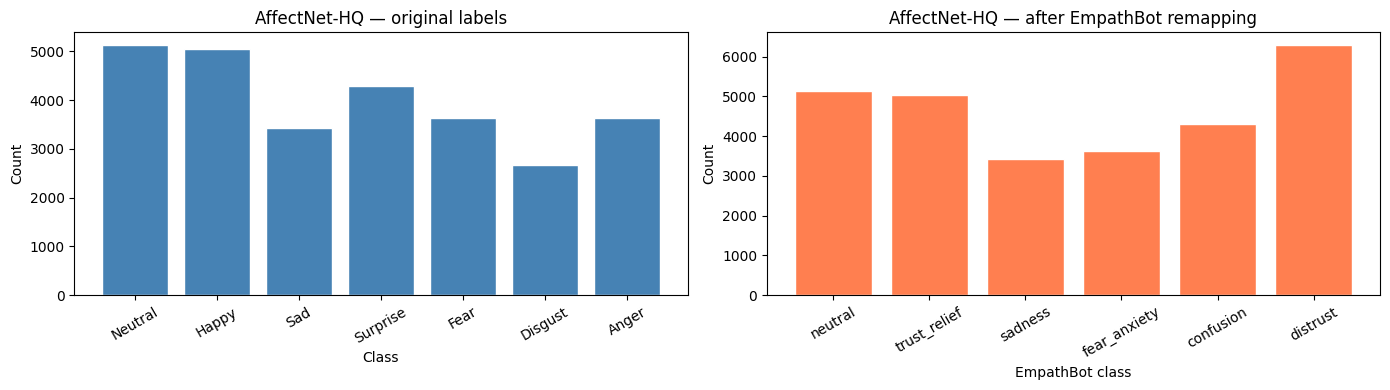

✅ Plot saved


In [11]:
# ── Plot AffectNet class distribution ─────────────────────────────────────────
if len(df_aff_raw) > 0:
    aff_names = {0:"Neutral",1:"Happy",2:"Sad",3:"Surprise",4:"Fear",5:"Disgust",6:"Anger",7:"Contempt"}
    counts = df_aff_raw.groupby("orig_label").size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Original labels
    axes[0].bar([aff_names[i] for i in counts.index], counts.values, color="steelblue", edgecolor="white")
    axes[0].set_title("AffectNet-HQ — original labels")
    axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)

    # After EmpathBot remapping
    eb_counts = df_aff_raw.groupby("eb_label").size()
    axes[1].bar([EMPATHBOT_CLASSES[i] for i in eb_counts.index], eb_counts.values, color="coral", edgecolor="white")
    axes[1].set_title("AffectNet-HQ — after EmpathBot remapping")
    axes[1].set_xlabel("EmpathBot class"); axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(BASE_DIR / "affectnet_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Plot saved")
else:
    print("⚠️  No data to plot — check dataset path")

## 4 — Verify RAF-DB dataset (Task 3)

Expected structure:
```
data/raw/rafdb/
    aligned/              ← aligned face images (use these)
    list_patition_label.txt  ← filename  split(1=train,0=test)  label(1-7)
```


In [14]:
# ── Paths (must match the rest of this notebook) ──────────────────────────────
BASE_DIR      = Path("data")
RAW_RAFDB     = BASE_DIR / "raw" / "rafdb"             # named emotion folders
RAF_HF_CACHE  = BASE_DIR / "raw" / "raf-db-7emotions"  # HuggingFace local cache

# ── HuggingFace label ordering for soerendip/raf-db-7emotions ────────────────
# HF index:  0=anger  1=disgust  2=fear  3=happiness  4=neutral  5=sadness  6=surprise
# EmpathBot mapping:
#   anger/disgust → distrust  |  fear → fear_anxiety  |  happiness → trust_relief
#   neutral → neutral         |  sadness → sadness     |  surprise → confusion
HF_RAF_LABEL_NAME   = {0:"anger", 1:"disgust", 2:"fear", 3:"happiness",
                        4:"neutral", 5:"sadness", 6:"surprise"}
HF_RAF_TO_EMPATHBOT = {0:5, 1:5, 2:3, 3:1, 4:0, 5:2, 6:4}

print("Loading RAF-DB from local HuggingFace cache…")
print(f"  Cache path: {RAF_HF_CACHE}")

from datasets import load_from_disk
ds_raf    = load_from_disk(str(RAF_HF_CACHE))
train_raf = ds_raf["train"]
print(f"✅ Dataset loaded  —  {len(train_raf):,} images  |  features: {list(train_raf.features.keys())}")

print(f"\nLabel distribution:")
from collections import Counter
lbl_counts = Counter(int(s["label"]) for s in train_raf)
for idx in sorted(lbl_counts):
    print(f"  {idx} ({HF_RAF_LABEL_NAME[idx]:12s}): {lbl_counts[idx]:,}")

Loading RAF-DB from local HuggingFace cache…
  Cache path: data/raw/raf-db-7emotions
✅ Dataset loaded  —  20,471 images  |  features: ['image', 'bbox', 'label']

Label distribution:
  0 (anger       ): 4,071
  1 (disgust     ): 877
  2 (fear        ): 355
  3 (happiness   ): 5,957
  4 (neutral     ): 5,132
  5 (sadness     ): 2,460
  6 (surprise    ): 1,619


In [ ]:
# # ── Save RAF-DB images to disk ────────────────────────────────────────────────
# saved = skipped = 0

# for idx, sample in enumerate(tqdm(train_raf, desc="Saving RAF-DB")):
#     img       = sample["image"]
#     hf_label  = int(sample["label"])
#     lbl_name  = HF_RAF_LABEL_NAME[hf_label]

#     out_path = RAW_RAFDB / lbl_name / f"{idx:06d}.jpg"

#     if out_path.exists():
#         skipped += 1
#         continue

#     if not isinstance(img, Image.Image):
#         img = Image.fromarray(img)
#     rgb = img.convert("RGB")
#     out_path.parent.mkdir(parents=True, exist_ok=True)
#     rgb.save(out_path, "JPEG", quality=95)
#     saved += 1

# print(f"\nRAF-DB  →  saved: {saved:,}  |  skipped (already exist): {skipped:,}")
# print(f"\nImages per class folder:")
# for hf_idx, name in HF_RAF_LABEL_NAME.items():
#     folder = RAW_RAFDB / name
#     n = len(list(folder.glob("*.jpg"))) if folder.exists() else 0
#     eb = HF_RAF_TO_EMPATHBOT[hf_idx]
#     print(f"  {hf_idx} ({name:12s}) → EB {eb} ({EMPATHBOT_CLASSES[eb]:15s}): {n:,}")
# print("\n✅ RAF-DB download complete")

Saving RAF-DB: 100%|██████████| 20471/20471 [00:26<00:00, 765.89it/s] 



RAF-DB  →  saved: 20,471  |  skipped (already exist): 0

Images per class folder:
  0 (anger       ) → EB 5 (distrust       ): 4,071
  1 (disgust     ) → EB 5 (distrust       ): 877
  2 (fear        ) → EB 3 (fear_anxiety   ): 355
  3 (happiness   ) → EB 1 (trust_relief   ): 5,957
  4 (neutral     ) → EB 0 (neutral        ): 5,132
  5 (sadness     ) → EB 2 (sadness        ): 2,460
  6 (surprise    ) → EB 4 (confusion      ): 1,619

✅ RAF-DB download complete


In [13]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path("data")
RAW_RAFDB  = BASE_DIR / "raw" / "rafdb"
HF_CACHE   = BASE_DIR / "raw" / "raf-db-7emotions"   # already downloaded by pipeline

# HF ClassLabel index → emotion name  (from dataset features)
HF_RAF_LABEL_NAME = {
    0: "anger", 1: "disgust", 2: "fear", 3: "happiness",
    4: "neutral", 5: "sadness", 6: "surprise"
}

# HF label index → EmpathBot class
HF_RAF_TO_EMPATHBOT = {
    0: 5,   # anger      → distrust
    1: 5,   # disgust    → distrust
    2: 3,   # fear       → fear_anxiety
    3: 1,   # happiness  → trust_relief
    4: 0,   # neutral    → neutral
    5: 2,   # sadness    → sadness
    6: 4,   # surprise   → confusion
}

print("Loading RAF-DB from local HuggingFace cache…")
print(f"  Cache path: {HF_CACHE}")
from datasets import load_from_disk
ds_raf = load_from_disk(str(HF_CACHE))
train_raf = ds_raf["train"]
print(f"✅ Dataset loaded  —  {len(train_raf):,} images  |  features: {list(train_raf.features.keys())}")
print(f"\nLabel distribution:")
from collections import Counter
lbl_counts = Counter(int(s["label"]) for s in train_raf)
for idx in sorted(lbl_counts):
    print(f"  {idx} ({HF_RAF_LABEL_NAME[idx]:12s}): {lbl_counts[idx]:,}")

Loading RAF-DB from local HuggingFace cache…
  Cache path: data/raw/raf-db-7emotions
✅ Dataset loaded  —  20,471 images  |  features: ['image', 'bbox', 'label']

Label distribution:
  0 (anger       ): 4,071
  1 (disgust     ): 877
  2 (fear        ): 355
  3 (happiness   ): 5,957
  4 (neutral     ): 5,132
  5 (sadness     ): 2,460
  6 (surprise    ): 1,619


In [16]:
def verify_rafdb(root: Path) -> pd.DataFrame:
    """Scan RAF-DB named-folder structure saved from HuggingFace."""
    RAF_FOLDER_MAP = {
        "anger":     5,   # distrust
        "disgust":   5,   # distrust
        "fear":      3,   # fear_anxiety
        "happiness": 1,   # trust_relief
        "neutral":   0,   # neutral
        "sadness":   2,   # sadness
        "surprise":  4,   # confusion
    }

    if not root.exists():
        print(f"⚠️  Folder not found: {root}")
        print("    Run the 'Save RAF-DB images' cell above first.")
        return pd.DataFrame()

    found_dirs = {d.name for d in root.iterdir() if d.is_dir()}
    if not found_dirs.intersection(RAF_FOLDER_MAP.keys()):
        print(f"⚠️  No emotion folders found in {root}")
        print(f"    Expected one of: {list(RAF_FOLDER_MAP.keys())}")
        return pd.DataFrame()

    VALID_EXT = {".jpg", ".jpeg", ".png"}
    records = []

    for cls_name, eb_id in tqdm(RAF_FOLDER_MAP.items(), desc="Scanning RAF-DB"):
        cls_dir = root / cls_name
        if not cls_dir.exists():
            print(f"  ⚠️  Missing: {cls_dir}")
            continue
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                records.append({
                    "path":          str(img_path),
                    "dataset":       "rafdb",
                    "orig_label":    cls_name,
                    "eb_label":      eb_id,
                    "raf_partition": 1,   # no official split in HF version; carve val from train
                    "split":         None,
                })

    df = pd.DataFrame(records)
    print(f"\nRAF-DB summary")
    print(f"  Total valid images : {len(df):,}")
    print(f"  Class distribution:")
    for cls_name, eb_id in sorted(RAF_FOLDER_MAP.items()):
        count = (df["orig_label"] == cls_name).sum()
        print(f"    {cls_name:12s} → EB {eb_id} ({EMPATHBOT_CLASSES.get(eb_id,'?'):15s}): {count:5,}")
    return df

df_raf_raw = verify_rafdb(RAW_RAFDB)

Scanning RAF-DB: 100%|██████████| 7/7 [00:00<00:00, 249.33it/s]


RAF-DB summary
  Total valid images : 20,471
  Class distribution:
    anger        → EB 5 (distrust       ): 4,071
    disgust      → EB 5 (distrust       ):   877
    fear         → EB 3 (fear_anxiety   ):   355
    happiness    → EB 1 (trust_relief   ): 5,957
    neutral      → EB 0 (neutral        ): 5,132
    sadness      → EB 2 (sadness        ): 2,460
    surprise     → EB 4 (confusion      ): 1,619


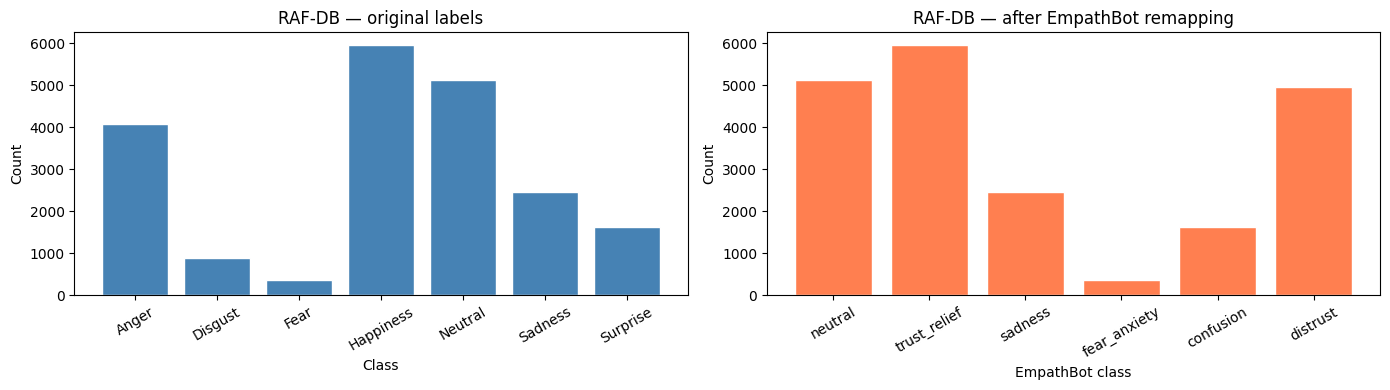

✅ Plot saved


In [18]:
# ── Plot RAF-DB class distribution ────────────────────────────────────────────
if len(df_raf_raw) > 0:
    counts = df_raf_raw.groupby("orig_label").size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar([i.title() for i in counts.index], counts.values, color="steelblue", edgecolor="white")
    axes[0].set_title("RAF-DB — original labels")
    axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)

    eb_counts = df_raf_raw.groupby("eb_label").size()
    axes[1].bar([EMPATHBOT_CLASSES[i] for i in eb_counts.index], eb_counts.values, color="coral", edgecolor="white")
    axes[1].set_title("RAF-DB — after EmpathBot remapping")
    axes[1].set_xlabel("EmpathBot class"); axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(BASE_DIR / "rafdb_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Plot saved")

## 5 — Verify SFEW dataset (Task 4)

SFEW is **evaluation only** — we never train or validate on it.

Expected structure:
```
data/raw/sfew/
    val/
        Angry/
        Disgust/
        Fear/
        Happy/
        Neutral/
        Sad/
        Surprise/
```


In [ ]:
# ── Save SFEW Val images to data/raw/sfew/val/ ────────────────────────────────
# Source: "1_SEFW Dataset/Val/{ClassName}/*.png"  (already on disk)
# Target: data/raw/sfew/val/{ClassName}/{idx:06d}.jpg

SFEW_SOURCE = Path("1_SEFW Dataset") / "Val"   # local source folder

SFEW_FOLDER_MAP = {
    "Angry":    5,   # distrust
    "Disgust":  5,   # distrust
    "Fear":     3,   # fear_anxiety
    "Happy":    1,   # trust_relief
    "Neutral":  0,   # neutral
    "Sad":      2,   # sadness
    "Surprise": 4,   # confusion
}

saved = skipped = 0
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

for cls_name, eb_id in tqdm(SFEW_FOLDER_MAP.items(), desc="Saving SFEW"):
    src_dir = SFEW_SOURCE / cls_name
    if not src_dir.exists():
        print(f"  ⚠️  Missing source folder: {src_dir}")
        continue

    src_imgs = sorted([f for f in src_dir.iterdir() if f.suffix.lower() in VALID_EXT])
    for idx, img_path in enumerate(src_imgs):
        out_path = RAW_SFEW / "val" / cls_name / f"{idx:06d}.jpg"

        if out_path.exists():
            skipped += 1
            continue

        img = Image.open(img_path).convert("RGB")
        out_path.parent.mkdir(parents=True, exist_ok=True)
        img.save(out_path, "JPEG", quality=95)
        saved += 1

print(f"\nSFEW  →  saved: {saved:,}  |  skipped (already exist): {skipped:,}")
print(f"\nImages per class folder  (data/raw/sfew/val/):")
for cls_name, eb_id in SFEW_FOLDER_MAP.items():
    folder = RAW_SFEW / "val" / cls_name
    n = len(list(folder.glob("*.jpg"))) if folder.exists() else 0
    print(f"  {cls_name:10s} → EB {eb_id} ({EMPATHBOT_CLASSES[eb_id]:15s}): {n:4,}")
print("\n✅ SFEW save complete")

In [19]:
def verify_sfew(root: Path) -> pd.DataFrame:
    """Scan SFEW val set folder structure."""
    # SFEW uses named folders matching these emotion strings
    SFEW_FOLDER_MAP = {
        "Angry":    5,   # distrust
        "Disgust":  5,   # distrust
        "Fear":     3,   # fear_anxiety
        "Happy":    1,   # trust_relief
        "Neutral":  0,   # neutral
        "Sad":      2,   # sadness
        "Surprise": 4,   # confusion
    }

    val_dir = root / "val"
    if not val_dir.exists():
        val_dir = root  # some releases put classes directly in root
        if not any(d.name in SFEW_FOLDER_MAP for d in val_dir.iterdir() if d.is_dir()):
            print(f"⚠️  SFEW folder not found or unexpected structure in {root}")
            return pd.DataFrame()

    VALID_EXT = {".jpg", ".jpeg", ".png"}
    records = []
    for cls_name, eb_id in SFEW_FOLDER_MAP.items():
        cls_dir = val_dir / cls_name
        if not cls_dir.exists():
            print(f"  ⚠️  Missing: {cls_dir}")
            continue
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                records.append({
                    "path":       str(img_path),
                    "dataset":    "sfew",
                    "orig_label": cls_name,
                    "eb_label":   eb_id,
                    "split":      "eval",
                })

    df = pd.DataFrame(records)
    print(f"\nSFEW summary (eval set only — never used for training)")
    print(f"  Total images: {len(df):,}")
    if len(df) > 0:
        for eb_id, count in sorted(Counter(df["eb_label"]).items()):
            print(f"    EmpathBot {eb_id} ({EMPATHBOT_CLASSES[eb_id]:15s}): {count:4,}")
    return df

df_sfew_raw = verify_sfew(RAW_SFEW)

⚠️  SFEW folder not found or unexpected structure in data/raw/sfew


## 6 — YOLO face detection filter + crop (Task 6) ⛔ Blocking

This is the **blocking task** — all training data must be processed before any model work.

For every image in AffectNet-HQ and RAF-DB:
1. Run YOLOv8 face detection
2. Discard if no face found, or face < 15% of image area
3. Discard if multiple faces with no clear subject
4. Crop to face bounding box + 20% padding
5. Resize to 224×224 (LANCZOS)
6. Save to `data/processed/`

> **Runtime note:** Processing ~44k images takes 20–60 min on CPU, 5–10 min on GPU.  
> Results are saved to disk so you only run this once.


In [1]:
BASE_DIR

NameError: name 'BASE_DIR' is not defined

In [ ]:
import urllib.request
import os
from ultralytics import YOLO

MODEL_PATH = BASE_DIR / "yolov12n-face.pt"
print(f"Checking for YOLOv8 face model at {MODEL_PATH} …")

# if not os.path.exists(MODEL_PATH):
#     url = "https://github.com/akanametov/yolo-face/"
#     print(f"Downloading {MODEL_PATH} from akanametov/yolo-face …")
#     urllib.request.urlretrieve(url, MODEL_PATH)
#     print("Download complete.")

face_model = YOLO(MODEL_PATH)
print("✅ YOLOv8 face model loaded")

Checking for YOLOv8 face model at data/yolov8n-face.pt …


FileNotFoundError: [Errno 2] No such file or directory: 'data/yolov8n-face.pt'

In [ ]:
def filter_and_crop_face(
    img_path: str,
    out_path: str,
    model,
    min_face_ratio: float = 0.15,
    pad_ratio: float = 0.20,
    target_size: int = 224,
) -> dict:
    """
    Detect, validate, crop, and save a face from one image.

    Returns a dict with keys: status, reason, face_ratio
      status: 'ok' | 'skip'
      reason: why it was skipped (if applicable)
    """
    img = cv2.imread(img_path)
    if img is None:
        return {"status": "skip", "reason": "unreadable", "face_ratio": 0}

    h, w = img.shape[:2]
    img_area = h * w

    results = model(img, verbose=False, conf=0.4)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        return {"status": "skip", "reason": "no_face", "face_ratio": 0}

    # Filter boxes by minimum face area ratio
    valid_boxes = []
    for box in boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box[:4])
        face_area = (x2 - x1) * (y2 - y1)
        ratio = face_area / img_area
        if ratio >= min_face_ratio:
            valid_boxes.append((x1, y1, x2, y2, ratio))

    if len(valid_boxes) == 0:
        return {"status": "skip", "reason": "face_too_small", "face_ratio": 0}

    if len(valid_boxes) > 1:
        # Keep only the largest face — discard if ambiguous (both > 15%)
        valid_boxes.sort(key=lambda b: b[4], reverse=True)
        # If second face is also substantial, skip
        if valid_boxes[1][4] > 0.10:
            return {"status": "skip", "reason": "multiple_faces", "face_ratio": valid_boxes[0][4]}

    x1, y1, x2, y2, ratio = valid_boxes[0]

    # Add padding
    pad_x = int((x2 - x1) * pad_ratio)
    pad_y = int((y2 - y1) * pad_ratio)
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    face_crop = img[y1:y2, x1:x2]
    if face_crop.size == 0:
        return {"status": "skip", "reason": "empty_crop", "face_ratio": ratio}

    # Resize to target size using LANCZOS equivalent (INTER_LANCZOS4 in cv2)
    face_resized = cv2.resize(face_crop, (target_size, target_size),
                               interpolation=cv2.INTER_LANCZOS4)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cv2.imwrite(out_path, face_resized)
    return {"status": "ok", "reason": None, "face_ratio": ratio}

print("✅ filter_and_crop_face() defined")

In [ ]:
def process_dataset(df_raw: pd.DataFrame, out_root: Path,
                    model, dataset_name: str) -> pd.DataFrame:
    """
    Run face filtering on every image in df_raw.
    Returns a DataFrame of successfully processed images.
    """
    processed = []
    skip_reasons = Counter()

    for _, row in tqdm(df_raw.iterrows(), total=len(df_raw),
                       desc=f"Processing {dataset_name}"):
        src = row["path"]
        eb_label = row["eb_label"]

        # Output path: processed/<dataset>/<eb_label>/<original_filename>
        fname = Path(src).name
        out_path = str(out_root / str(eb_label) / fname)

        # Skip if already processed (resumable)
        if os.path.exists(out_path):
            new_row = row.to_dict()
            new_row["path"] = out_path
            processed.append(new_row)
            continue

        result = filter_and_crop_face(src, out_path, model)

        if result["status"] == "ok":
            new_row = row.to_dict()
            new_row["path"] = out_path
            new_row["face_ratio"] = result["face_ratio"]
            processed.append(new_row)
        else:
            skip_reasons[result["reason"]] += 1

    df_proc = pd.DataFrame(processed)

    kept   = len(df_proc)
    total  = len(df_raw)
    print(f"\n{dataset_name} filtering results:")
    print(f"  Input  : {total:,} images")
    print(f"  Kept   : {kept:,} ({100*kept/total:.1f}%)")
    print(f"  Skipped: {total - kept:,}")
    for reason, count in skip_reasons.most_common():
        print(f"    {reason}: {count:,}")
    return df_proc

print("✅ process_dataset() defined")

In [ ]:
# ── Process AffectNet-HQ ──────────────────────────────────────────────────────
# NOTE: This will take a while on first run. Results are cached to disk.
if len(df_aff_raw) > 0:
    df_aff_proc = process_dataset(df_aff_raw, AFFECTNET_PROC, face_model, "AffectNet-HQ")
    print(f"\n✅ AffectNet-HQ processed: {len(df_aff_proc):,} images saved to {AFFECTNET_PROC}")
else:
    print("⚠️  df_aff_raw is empty — skipping (check your dataset path in Cell 1.1)")
    df_aff_proc = pd.DataFrame()

In [ ]:
# ── Process RAF-DB ────────────────────────────────────────────────────────────
if len(df_raf_raw) > 0:
    df_raf_proc = process_dataset(df_raf_raw, RAFDB_PROC, face_model, "RAF-DB")
    print(f"\n✅ RAF-DB processed: {len(df_raf_proc):,} images saved to {RAFDB_PROC}")
else:
    print("⚠️  df_raf_raw is empty — skipping")
    df_raf_proc = pd.DataFrame()

In [ ]:
# ── Process SFEW ─────────────────────────────────────────────────────────────
if len(df_sfew_raw) > 0:
    df_sfew_proc = process_dataset(df_sfew_raw, SFEW_PROC, face_model, "SFEW")
    print(f"\n✅ SFEW processed: {len(df_sfew_proc):,} images saved to {SFEW_PROC}")
    # Update paths to processed images
    df_sfew_raw = df_sfew_proc
else:
    print("⚠️  df_sfew_raw is empty — skipping")
    df_sfew_proc = pd.DataFrame()

In [ ]:
# ── Quick visual check: show a few processed crops ────────────────────────────
def show_sample_crops(df: pd.DataFrame, dataset_name: str, n: int = 12):
    if len(df) == 0:
        print("No data to show."); return

    sample = df.sample(min(n, len(df)), random_state=42)
    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f'EB {row["eb_label"]}\n{EMPATHBOT_CLASSES[row["eb_label"]]}',
                           fontsize=8)
        axes[i].axis("off")
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"{dataset_name} — sample processed crops (224×224)")
    plt.tight_layout()
    plt.savefig(BASE_DIR / f"{dataset_name.lower().replace('-','_')}_crops.png",
                dpi=120, bbox_inches="tight")
    plt.show()

if len(df_aff_proc) > 0:
    show_sample_crops(df_aff_proc, "AffectNet-HQ")
if len(df_raf_proc) > 0:
    show_sample_crops(df_raf_proc, "RAF-DB")

## 7 — Merge datasets + stratified split + master_split.csv (Task 7)

### Strategy
- **AffectNet-HQ**: random stratified 70 / 15 / 15 split (seed=42)
- **RAF-DB**: respect the official partition (`raf_partition` column: 1=train, 0=test).  
  Carve val from the official train portion (stratified).
- **SFEW**: remains `eval` — never enters train/val/test splits.
- Save everything to `master_split.csv` so every experiment uses identical data.


In [ ]:
def assign_splits_affectnet(df: pd.DataFrame,
                             val_ratio: float = 0.15,
                             test_ratio: float = 0.15,
                             seed: int = 42) -> pd.DataFrame:
    """Stratified 70/15/15 split for AffectNet (no official split)."""
    df = df.copy()

    # First split off test
    df_trainval, df_test = train_test_split(
        df, test_size=test_ratio, stratify=df["eb_label"], random_state=seed
    )
    # Then split val from trainval
    val_ratio_adj = val_ratio / (1 - test_ratio)
    df_train, df_val = train_test_split(
        df_trainval, test_size=val_ratio_adj, stratify=df_trainval["eb_label"], random_state=seed
    )

    df.loc[df_train.index, "split"] = "train"
    df.loc[df_val.index,   "split"] = "val"
    df.loc[df_test.index,  "split"] = "test"
    return df


def assign_splits_rafdb(df: pd.DataFrame,
                         val_ratio: float = 0.15,
                         seed: int = 42) -> pd.DataFrame:
    """
    Respect RAF-DB's official train/test split.
    Carve val from official train portion (stratified).
    """
    df = df.copy()

    # Official test → always test
    df_official_test  = df[df["raf_partition"] == 0].copy()
    df_official_train = df[df["raf_partition"] == 1].copy()

    # Carve val from official train
    df_train, df_val = train_test_split(
        df_official_train,
        test_size=val_ratio,
        stratify=df_official_train["eb_label"],
        random_state=seed,
    )

    df.loc[df_train.index,         "split"] = "train"
    df.loc[df_val.index,           "split"] = "val"
    df.loc[df_official_test.index, "split"] = "test"
    return df


print("✅ Split functions defined")

In [ ]:
# ── Assign splits ─────────────────────────────────────────────────────────────
dfs_to_merge = []

if len(df_aff_proc) > 0:
    df_aff_split = assign_splits_affectnet(df_aff_proc)
    dfs_to_merge.append(df_aff_split)
    print("AffectNet-HQ splits:")
    print(df_aff_split["split"].value_counts().sort_index().to_string())

if len(df_raf_proc) > 0:
    # Add raf_partition col if missing (for datasets without official split info)
    if "raf_partition" not in df_raf_proc.columns:
        df_raf_proc["raf_partition"] = 1  # treat all as train, carve val
    df_raf_split = assign_splits_rafdb(df_raf_proc)
    dfs_to_merge.append(df_raf_split)
    print("\nRAF-DB splits:")
    print(df_raf_split["split"].value_counts().sort_index().to_string())

# Add SFEW (eval only)
if len(df_sfew_raw) > 0:
    dfs_to_merge.append(df_sfew_raw)

if not dfs_to_merge:
    print("\n⚠️  No processed data available. Run the face-filter cells above first.")
else:
    df_master = pd.concat(dfs_to_merge, ignore_index=True)
    # Fill any missing columns with NaN
    for col in ["face_ratio", "raf_partition"]:
        if col not in df_master.columns:
            df_master[col] = float("nan")

    print(f"\n── Combined pool ──")
    print(f"  Total images : {len(df_master):,}")
    print(f"  By dataset   :")
    print(df_master["dataset"].value_counts().to_string())
    print(f"\n  By split     :")
    print(df_master["split"].value_counts().to_string())

In [ ]:
# ── Save master_split.csv ─────────────────────────────────────────────────────
if "df_master" in dir() and len(df_master) > 0:
    cols = ["path", "dataset", "orig_label", "eb_label", "split", "face_ratio"]
    cols = [c for c in cols if c in df_master.columns]
    df_master[cols].to_csv(SPLIT_CSV, index=False)
    print(f"✅ master_split.csv saved → {SPLIT_CSV}")
    print(f"   Rows: {len(df_master):,} | Columns: {cols}")
    print(df_master[cols].head(3).to_string())
else:
    print("⚠️  df_master not available — run the merge cell above")

## 8 — Compute inverse-frequency class weights

Used in `nn.CrossEntropyLoss(weight=...)` to counter class imbalance.
Computed from the **training split only** (never val or test).


In [ ]:
if "df_master" in dir() and len(df_master) > 0:
    df_train_only = df_master[df_master["split"] == "train"]

    class_counts = df_train_only["eb_label"].value_counts().sort_index()
    total = len(df_train_only)

    # Inverse-frequency weights: w_c = total / (num_classes * count_c)
    weights = {}
    for cls_id in range(NUM_CLASSES):
        count = class_counts.get(cls_id, 1)
        weights[cls_id] = total / (NUM_CLASSES * count)

    # Normalise so mean weight = 1
    mean_w = np.mean(list(weights.values()))
    weights = {k: v / mean_w for k, v in weights.items()}

    print("Class weights for CrossEntropyLoss (train split only):")
    print(f"{'Class':>6}  {'Name':20}  {'Count':>8}  {'Weight':>8}")
    print("-" * 50)
    for cls_id, w in sorted(weights.items()):
        count = class_counts.get(cls_id, 0)
        print(f"  {cls_id:>4}  {EMPATHBOT_CLASSES[cls_id]:20}  {count:8,}  {w:8.4f}")

    # Save as JSON and as torch tensor
    with open(WEIGHTS_JSON, "w") as f:
        json.dump({str(k): v for k, v in weights.items()}, f, indent=2)

    weight_tensor = torch.tensor([weights[i] for i in range(NUM_CLASSES)], dtype=torch.float32)

    print(f"\n✅ Weights saved → {WEIGHTS_JSON}")
    print(f"\nTo use in training:")
    print(f"  weight_tensor = {weight_tensor.tolist()}")
    print(f"  criterion = nn.CrossEntropyLoss(weight=weight_tensor.to(device))")

    # ── Visualise class balance ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    split_counts = df_master[df_master["split"].isin(["train","val","test"])].groupby(
        ["split", "eb_label"]).size().unstack(fill_value=0)
    split_counts.columns = [EMPATHBOT_CLASSES[c] for c in split_counts.columns]
    split_counts.T.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
    axes[0].set_title("Image count per class per split")
    axes[0].set_xlabel("EmpathBot class")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="Split")

    class_names = [EMPATHBOT_CLASSES[i] for i in sorted(weights.keys())]
    weight_vals  = [weights[i] for i in sorted(weights.keys())]
    axes[1].bar(class_names, weight_vals, color="steelblue", edgecolor="white")
    axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1, label="weight=1 (balanced)")
    axes[1].set_title("CrossEntropyLoss class weights")
    axes[1].set_xlabel("EmpathBot class")
    axes[1].set_ylabel("Weight")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(BASE_DIR / "class_balance.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Balance plot saved")
else:
    print("⚠️  df_master not available")

## 9 — PyTorch Dataset class + DataLoader (ready for Task 11)

A drop-in `EmpathBotDataset` class that reads from `master_split.csv`.
Paste this into your training script.


In [ ]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

class EmpathBotDataset(Dataset):
    """
    Reads from master_split.csv.
    split: 'train' | 'val' | 'test' | 'eval'
    augment: apply strong augmentation (train split only)
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, csv_path: str, split: str, augment: bool = False):
        df = pd.read_csv(csv_path)
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.augment = augment

        if augment:
            self.transform = T.Compose([
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(degrees=15),
                T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
                T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                T.ToTensor(),
                T.Normalize(mean=self.MEAN, std=self.STD),
            ])
        else:
            self.transform = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=self.MEAN, std=self.STD),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")
        label = int(row["eb_label"])
        return self.transform(img), label


# ── Smoke test: one batch from each split ─────────────────────────────────────
if SPLIT_CSV.exists():
    for split in ["train", "val", "test"]:
        try:
            ds = EmpathBotDataset(str(SPLIT_CSV), split=split,
                                   augment=(split == "train"))
            if len(ds) == 0:
                print(f"  {split:5s}: 0 samples (dataset path may not exist yet)")
                continue
            loader = DataLoader(ds, batch_size=8, shuffle=(split=="train"), num_workers=0)
            imgs, labels = next(iter(loader))
            print(f"  {split:5s}: {len(ds):6,} samples | "
                  f"batch shape {tuple(imgs.shape)} | labels {labels.tolist()}")
        except Exception as e:
            print(f"  {split:5s}: error — {e}")
    print("\n✅ EmpathBotDataset ready for training")
else:
    print(f"⚠️  {SPLIT_CSV} not found — run the merge/split cells first")

In [ ]:
# ── Strong augmentation for minority classes (CLAHE + perspective) ─────────────
# Apply this in your training loop for classes with weight > 1.5
import albumentations as A
from albumentations.pytorch import ToTensorV2

strong_aug = A.Compose([
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.6),     # dim-room lighting
    A.Perspective(scale=(0.05, 0.15), p=0.5),                   # camera angle variation
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

print("Strong augmentation pipeline (for minority classes):")
for t in strong_aug.transforms:
    print(f"  {t.__class__.__name__}")
print("\nUsage in training loop:")
print("  augmented = strong_aug(image=np.array(pil_img))")
print("  tensor    = augmented['image']   # shape: [3, 224, 224]")

## 10 — Pipeline summary & next steps


In [ ]:
print("=" * 60)
print("  EmpathBot Dataset Pipeline — COMPLETE SUMMARY")
print("=" * 60)

if SPLIT_CSV.exists():
    df_check = pd.read_csv(SPLIT_CSV)
    total = len(df_check)
    print(f"\n  master_split.csv : {SPLIT_CSV}")
    print(f"  Total records    : {total:,}")
    print()
    for ds in df_check["dataset"].unique():
        sub = df_check[df_check["dataset"] == ds]
        print(f"  {ds.upper()}")
        for sp in ["train", "val", "test", "eval"]:
            n = (sub["split"] == sp).sum()
            if n > 0:
                print(f"    {sp:6s}: {n:6,}")
    print()
    print("  Class distribution (train split):")
    train_df = df_check[df_check["split"] == "train"]
    for cls_id in range(NUM_CLASSES):
        n = (train_df["eb_label"] == cls_id).sum()
        print(f"    {cls_id} {EMPATHBOT_CLASSES[cls_id]:20s}: {n:6,}")
else:
    print("  ⚠️  master_split.csv not yet created.")

if WEIGHTS_JSON.exists():
    with open(WEIGHTS_JSON) as f:
        wts = json.load(f)
    print(f"\n  class_weights.json : {WEIGHTS_JSON}")
    for k, v in wts.items():
        print(f"    Class {k} ({EMPATHBOT_CLASSES[int(k)]:20s}): {v:.4f}")

print()
print("  Files in data/")
for f in sorted(BASE_DIR.rglob("*.csv")) + sorted(BASE_DIR.rglob("*.json")) + sorted(BASE_DIR.rglob("*.png")):
    size = f.stat().st_size
    print(f"    {f.relative_to(BASE_DIR)}  ({size/1024:.1f} KB)")

print()
print("  Next steps:")
print("  Task  8 — Train ResNet-18 baseline on RAF-DB (use EmpathBotDataset)")
print("  Task  9 — Evaluate POSTER++ pretrained weights on RAF-DB test set")
print("  Task 10 — Evaluate Ada-DF on RAF-DB + AffectNet val + SFEW")
print("  Task 11 — Design & train your main EmpathBot face model")
print("  Task 12 — Build 4-model comparison table")
print()
print("  Load weights for training:")
print(f"    weight_tensor = torch.tensor(list(json.load(open('{WEIGHTS_JSON}')).values()))")
print( "    criterion = nn.CrossEntropyLoss(weight=weight_tensor.to(device))")
print("=" * 60)